In [1]:
import numpy as np
from scipy.optimize import fsolve, brentq
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

hbar = 1 # in []

In [2]:
def k(E,m,hbar):
    return np.sqrt(2*m*E)/hbar
    
def q(E,V0,m,hbar):
    return np.sqrt(2*m*(V0-E))/hbar


class even:
    def __init__(self, E, n, V0, m, L):
        self.n = n+1
        self.L = L
        self.lower = -L/2.0
        self.upper = L/2.0    
        self.k = k(E,m,hbar)
        self.q = q(E,V0,m,hbar)
        self.normalize()
    
    def normalize(self):
        self.D = 1.0/np.sqrt(self.L/2.0 + 1.0/self.q)
        self.A = np.exp(self.q*self.L/2.0)*np.cos(self.k*self.L/2.0)*self.D
    
    def value(self,x):
        if x < self.lower:
            return self.A*np.exp(self.q*x)
        elif self.lower <= x and x <= self.upper:
            return self.D*np.cos(self.k*x)
        elif self.upper < x:
            return self.A*np.exp(-self.q*x)
    
    def print_normalization(self):
        print(f"A = {self.A}")
        print(f"D = {self.D}")
    
    
    
class odd:
    def __init__(self, E, n, V0, m, L):
        self.n = n+1
        self.L = L
        self.lower = -L/2.0
        self.upper = L/2.0    
        self.k = k(E,m,hbar)
        self.q = q(E,V0,m,hbar)
        self.normalize()
    
    def normalize(self):
        self.C = 1.0/np.sqrt(self.L/2.0 + 1.0/self.q)
        self.A = -np.exp(self.q*self.L/2.0)*np.sin(self.k*self.L/2.0)*self.C

    
    def value(self,x):
        if x < self.lower:
            return self.A*np.exp(self.q*x)
        elif self.lower <= x and x <= self.upper:
            return self.C*np.sin(self.k*x)
        elif self.upper < x:
            return -self.A*np.exp(-self.q*x)

    def print_normalization(self):
        print(f"A = {self.A}")
        print(f"C = {self.C}")


In [24]:
def plot_eigenstate(phi,prob=False):
    fig, axs = plt.subplots(1,2,layout='constrained',figsize=(9,4))

    inf_factor = 2
    xmin = -inf_factor*L/2.0
    xmax = inf_factor*L/2.0
    x_array = np.linspace(xmin,xmax,200)
    
    for ax in axs:
        ax.set_xlim(xmin,xmax)
        ax.set_xlabel('x')
        ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
        ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.2)) 
        ax.axvline(-phi.L/2.0,color='black',ls='--',label=r"$V_0$")
        ax.axvline(phi.L/2.0,color='black',ls='--')
        ax.axhline(0,color='black')
    
    
    # Wavefunction
    y = np.array( [ phi.value(x) for x in x_array ], dtype=np.float32)
    axs[0].plot(x_array,y,label=rf"$\phi_{{E_{phi.n}}}$")
    axs[0].legend()
    axs[0].set_ylabel(r"$Re(\phi)$")
    
    # Probability
    y = np.array( [ phi.value(x)**2 for x in x_array ], dtype=np.float32)
    axs[1].plot(x_array,y,label=rf"$\phi_{{E_{phi.n}}}$")
    axs[1].set_ylabel(r"$|\phi|^2$")
    indices = np.where(x_array < phi.lower)
    axs[1].fill_between(x_array[indices],y[indices],color="#c8c8c8")
    indices = np.where(x_array > phi.upper)
    axs[1].fill_between(x_array[indices],y[indices],color="#c8c8c8")
    
    plt.show()

In [12]:
def circle(z,z0):
    return np.sqrt(z0**2 - z**2)

def func1(z):
    return z*np.sin(z)/np.cos(z)

def func2(z):
    return -z*np.cos(z)/np.sin(z)

def equation_even(z,z0):
    return func1(z) - circle(z,z0)

def equation_odd(z,z0):
    return func2(z) - circle(z,z0)

def z0_func(V0,m,L):
    return np.sqrt(2*m*V0*L**2/(4*hbar**2))    
    
def energy(z,m,L):
    return 4*z**2*hbar**2/(2*m*L**2)

In [13]:
def plot_energy_roots(V0,m,L):
    z0 = z0_func(V0,m,L)

    z_array = np.linspace(0,z0,100)
    circl = [ circle(z,z0) for z in z_array ]
    
    fig, ax = plt.subplots(layout='constrained')

    ax.set_aspect('equal')
    ax.set_xlim(0,1.2*z0)
    ax.set_ylim(0,1.2*z0)
    ax.set_xlabel('z')
    ax.set_ylabel('f(z)')
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.2))
    
    # Plot circle
    circ, = ax.plot(z_array,circl,label=r"$\sqrt{z^2 - z_0^2}$")

    # Plot solutions with tangent
    step_size = np.pi/50.0
    n = 0
    while n*np.pi < z0:
        lower = n*np.pi
        upper = min((n+1/2)*np.pi,z0)
        N = int(np.ceil((upper-lower)/step_size))
        xs = [0]*N
        ys = [0]*N
        for i in range(0,N):
            x = lower + i*step_size
            xs[i] = x
            ys[i] = func1(x)
        even, = ax.plot(xs,ys,color='red',label=r"$z \, \mathrm{tan} (z)$")
        n = n + 1
    
    # Plot solutions with cotangent
    n = 0
    while n*np.pi < z0:
        lower = (n+1/2)*np.pi
        upper = min((n+1)*np.pi,z0)
        N = int(np.ceil((upper-lower)/step_size))
        xs = [0]*N
        ys = [0]*N
        for i in range(0,N):
            x = lower + i*step_size
            xs[i] = x
            ys[i] = func2(x)
        odd, = ax.plot(xs,ys,color='orange',label="$-z \, \mathrm{cot} (z)$")
        n = n + 1
    
    # Plot roots (Energy)
    x_roots,y_roots = get_roots(V0,m,L)    
    ax.scatter(x_roots,y_roots)
    
    ax.legend(handles=[circ,even,odd])
    
    plt.show()

In [14]:
def get_roots(V0,m,L):
    z0 = z0_func(V0,m,L)

    # Solve in the range [nπ,(n+1)π]
    roots_even = []
    n = 0
    while n*np.pi < z0:
        lower = n*np.pi
        upper = min((n+1/2)*np.pi,z0)
        root = brentq(equation_even,lower,upper,args=(z0))
        roots_even.append(root)
        n = n + 1
    
    roots_odd  = []
    n = 0
    while (n+1/2)*np.pi < z0:
        lower = (n+1/2)*np.pi
        upper = min((n+1)*np.pi,z0)
        #print(n,lower,upper,equation_odd(lower,z0),equation_odd(upper,z0))
        root = brentq(equation_odd,lower,upper,args=(z0))
        roots_odd.append(root)
        n = n + 1
    
    x_roots = np.sort(np.concatenate((roots_even,roots_odd)))
    y_roots = [ circle(z,z0) for z in x_roots ]

    return x_roots,y_roots

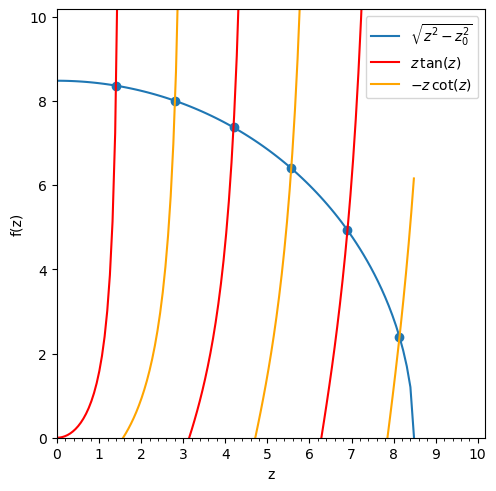

Energy 1: 3.95 (z=1.40)
Energy 2: 15.73 (z=2.80)
Energy 3: 35.20 (z=4.20)
Energy 4: 61.99 (z=5.57)
Energy 5: 95.32 (z=6.90)
Energy 6: 132.52 (z=8.14)


In [15]:
L = 1 # in [nm]
V0 = 144 # in [eV]
m = 1 # in []

plot_energy_roots(V0,m,L)

z_roots,dum = get_roots(V0,m,L)
N_energies = len(z_roots)
energies = [0]*N_energies
for i in range(0,N_energies):
    energies[i] = energy(z_roots[i],m,L)
    print(f"Energy {i+1}: {energies[i]:.2f} (z={z_roots[i]:.2f})")

In [16]:
phis = [0]*N_energies

for i in range(0,N_energies):
    if i % 2 == 0:
        # even
        phis[i] = even(energies[i],i,V0,m,L)
    else:
        # odd
        phis[i] = odd(energies[i],i,V0,m,L)
    

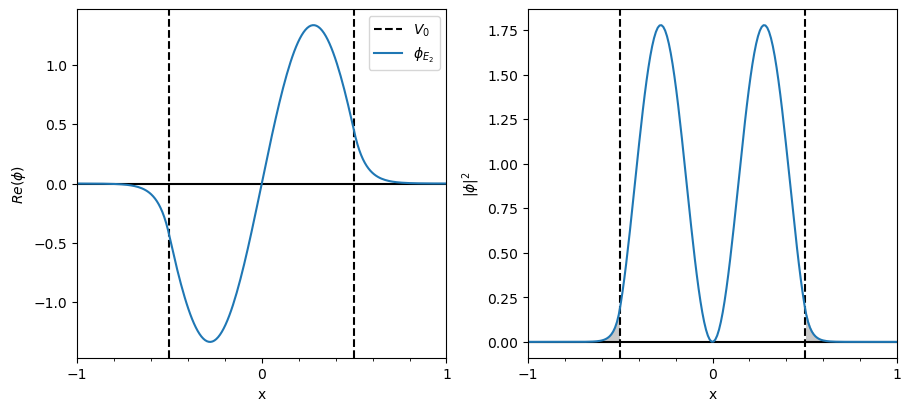

A = -1324.8477818767503
C = 1.3334105096376012


In [26]:
target_state = phis[1]
plot_eigenstate(target_state)
target_state.print_normalization()